In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay

In [3]:
# load the dataset from Seaborn
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Inspect the data
titanic.info()
titanic.describe()
titanic.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


In [5]:
# Basic data cleaning
# Drop rows with missing 'age' or 'embarked' values for simplicity
titanic_clean = titanic.dropna(subset=['age', 'embarked']).copy()

# Select features (predictors) and target
features = ['pclass', 'sex', 'age', 'fare', 'embarked']
target = 'survived'

df = titanic_clean[features + [target]].copy()
df.head()

# This keeps only important columns and removes rows with critical missing data.

,pclass,sex,age,fare,embarked,survived
0,3,male,22.0,7.2500,S,0
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,1
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0


In [6]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)   # get_dummies turns each category into binary variable (0/1)
df_encoded.head()

,pclass,age,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,7.2500,0,True,False,True
1,1,38.0,71.2833,1,False,False,False
2,3,26.0,7.9250,1,False,False,True
3,1,35.0,53.1000,1,False,False,True
4,3,35.0,8.0500,0,True,False,True


In [7]:
# Split into training and testing sets
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# You train your model on 80% of the data and reserve 20% to test how well it performs on unseen cases.

Train size: (569, 6)
Test size: (143, 6)


In [8]:
# Train a logistic regression model
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# simplest predictive model-useful as a baseline
# Accuracy = 0.8 means your model predicts 80% accuracy

Accuracy: 0.7622377622377622
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        85
           1       0.71      0.69      0.70        58

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



In [9]:
# Train a random forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Random Forest uses many decison trees to boost performance
# compare its accurayc to logistic regression

Accuracy: 0.7552447552447552
              precision    recall  f1-score   support

           0       0.79      0.80      0.80        85
           1       0.70      0.69      0.70        58

    accuracy                           0.76       143
   macro avg       0.75      0.74      0.75       143
weighted avg       0.75      0.76      0.75       143



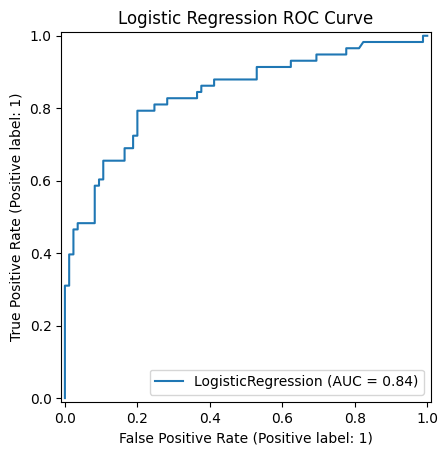

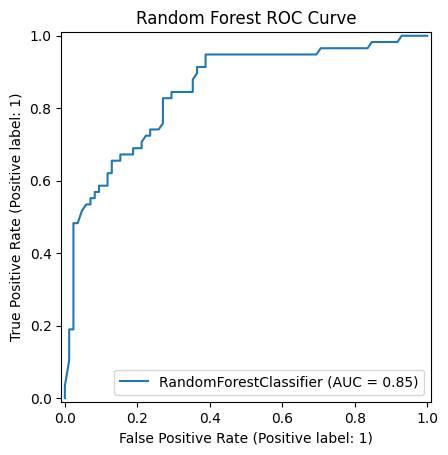

In [10]:
# Visualize performance
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.title('Logistic Regression ROC Curve')
plt.show()

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title('Random Forest ROC Curve')
plt.show()

# ROC curve shows how well model distingueshes survivors vs. non-survivors
# Higher curve = better model

I learned how to load, clean, and model data end-to-end in Python. I practiced encoding categorical variables, splitting data, training logistic regression and random forest models, and interpreting feature importance. Next week, I’ll apply the same steps to the Shigella dataset (GEMS + WASH), replacing passenger features with demographic and sanitation variables.